##### Perform Exploratory Data Analysis of the given dataset and develop recommendations to improve the sales and service opportunities
##### This dataset contains the Segmentation details of Customers and their Sales and Service opportunities
Note: <br> 
* The messy data was cleaned and combined in a different project
* One Customer Id has one record in the cleaned dataset with details of all Opportunities and Sales
* There are 653 Customer IDs with no details of Opportunities, Sales, Equipment or Sales Channel in the provided dataset and is discarded in further analysis

In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [21]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)  # Ignore the unnecessary noise of future warnings in the output

In [22]:
os.chdir("../Data")
# os.getcwd()
# Read each sheet of the input excel file into a dataframe

In [23]:
custdf = pd.read_excel("Sales Opp Data.xlsx", sheet_name='SalesOpp')
custdf

,Customer ID,City,Segmentation,Undercarriage Opportunity,Undercarriage Sales,Engine Opportunity,Engine Sales,GET Opportunity,GET Sales,Drive Train Opportunity,...,"Structural, Appearance, and Other Parts Sales",Labor Opportunity,Labor Sales,Parts Sales,Parts Opportunity,Units,Work Order sales,Over the Counter Sales,Total Parts Sales,Total Parts Opportunity
0,310480,03 ADANA,Unknown Segment,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,450650,02 IZMIR,Do It Myself,0,0,8052,2423,3750,0,9776,...,694,15101,3344,13954,34877,0,0,0,13954,34877
2,010020,03 ADANA,Do It Myself,0,0,102,0,30,0,54,...,0,222,0,0,426,1,0,0,0,426
3,010030,01 ANKARA,Do It Myself,2971,0,3940,0,1883,0,1810,...,0,8728,0,603,21000,9,0,603,603,21000
4,010050,03 ADANA,Do It Myself,0,0,345,0,219,0,6,...,0,552,0,0,1291,2,0,0,0,1291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9978,PUZ240,Unknown City,Unknown Segment,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9979,PUZ540,Unknown City,Unknown Segment,0,0,0,0,0,0,0,...,0,0,0,0,0,35,0,0,0,0
9980,PUZ630,Unknown City,Unknown Segment,0,0,0,0,0,0,0,...,0,0,0,0,0,0,718,632,0,0
9981,RENTAL,00 ISTANBUL,Do It Myself,3671,0,11101,30350,25028,0,7959,...,694,30031,0,78154,110390,0,0,0,78154,110390


In [24]:
custdf.describe(include="all")

,Customer ID,City,Segmentation,Undercarriage Opportunity,Undercarriage Sales,Engine Opportunity,Engine Sales,GET Opportunity,GET Sales,Drive Train Opportunity,...,"Structural, Appearance, and Other Parts Sales",Labor Opportunity,Labor Sales,Parts Sales,Parts Opportunity,Units,Work Order sales,Over the Counter Sales,Total Parts Sales,Total Parts Opportunity
count,9983,9983,9983,9983.000000,9983.000000,9983.000000,9983.000000,9983.000000,9983.000000,9983.000000,...,9983.000000,9.983000e+03,9983.000000,9.983000e+03,9.983000e+03,9983.000000,9.983000e+03,9.983000e+03,9.983000e+03,9.983000e+03
unique,9983,10,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ZENGEL,Unknown City,Do It Myself,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2124,6016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,745.145748,333.072824,1537.130522,1309.860964,594.382150,336.637183,953.114094,...,411.803266,3.053285e+03,1125.675949,4.298336e+03,7.287754e+03,2.300811,3.728439e+03,4.211507e+03,4.298336e+03,7.287754e+03
std,NaN,NaN,NaN,9232.830276,8699.875526,13414.397738,17114.322540,5259.405004,7444.120373,8506.389219,...,6305.898453,2.246007e+04,11419.751461,5.925264e+04,6.182094e+04,9.499284,1.868211e+05,2.121633e+05,5.925264e+04,6.182094e+04
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,-908.000000,0.000000,-2042.000000,0.000000,...,-602.000000,0.000000e+00,0.000000,-2.652000e+03,0.000000e+00,0.000000,0.000000e+00,-2.056000e+03,-2.652000e+03,0.000000e+00
25%,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,NaN,NaN,NaN,0.000000,0.000000,175.000000,0.000000,7.000000,0.000000,2.000000,...,0.000000,4.100000e+02,0.000000,0.000000e+00,8.960000e+02,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,8.960000e+02
75%,NaN,NaN,NaN,0.000000,0.000000,880.000000,0.000000,324.000000,0.000000,426.500000,...,0.000000,2.050000e+03,0.000000,1.860000e+02,4.272500e+03,2.000000,0.000000e+00,2.400000e+01,1.860000e+02,4.272500e+03


In [25]:
custdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9983 entries, 0 to 9982
Data columns (total 28 columns):
 #   Column                                               Non-Null Count  Dtype 
---  ------                                               --------------  ----- 
 0   Customer ID                                          9983 non-null   object
 1   City                                                 9983 non-null   object
 2   Segmentation                                         9983 non-null   object
 3   Undercarriage Opportunity                            9983 non-null   int64 
 4   Undercarriage Sales                                  9983 non-null   int64 
 5   Engine Opportunity                                   9983 non-null   int64 
 6   Engine Sales                                         9983 non-null   int64 
 7   GET  Opportunity                                     9983 non-null   int64 
 8   GET Sales                                            9983 non-null   int64 
 9

In [26]:
# Find if any customer has 0 values for all Opportunities and Sales and other details

numeric_cols = custdf.select_dtypes(include=[np.number])
mask_all_zeros = (numeric_cols == 0).all(axis=1)

custdf[mask_all_zeros]
# There are 653 Customer IDs with no details of Opportunities, Sales, Equipment or Sales Channel in the provided dataset and can be discarded

#custdf[mask_all_zeros].groupby(['City']).size() 
#custdf[mask_all_zeros].groupby(['Segmentation']).size() 

#Discarding Customers with no useful information
customerdf = custdf[~mask_all_zeros]
customerdf

,Customer ID,City,Segmentation,Undercarriage Opportunity,Undercarriage Sales,Engine Opportunity,Engine Sales,GET Opportunity,GET Sales,Drive Train Opportunity,...,"Structural, Appearance, and Other Parts Sales",Labor Opportunity,Labor Sales,Parts Sales,Parts Opportunity,Units,Work Order sales,Over the Counter Sales,Total Parts Sales,Total Parts Opportunity
1,450650,02 IZMIR,Do It Myself,0,0,8052,2423,3750,0,9776,...,694,15101,3344,13954,34877,0,0,0,13954,34877
2,010020,03 ADANA,Do It Myself,0,0,102,0,30,0,54,...,0,222,0,0,426,1,0,0,0,426
3,010030,01 ANKARA,Do It Myself,2971,0,3940,0,1883,0,1810,...,0,8728,0,603,21000,9,0,603,603,21000
4,010050,03 ADANA,Do It Myself,0,0,345,0,219,0,6,...,0,552,0,0,1291,2,0,0,0,1291
5,010060,03 ADANA,Do It For Me,0,0,3198,2661,3154,0,2380,...,603,8354,14464,10780,22530,15,17633,7611,10780,22530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9977,PUZ073,Unknown City,Unknown Segment,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
9979,PUZ540,Unknown City,Unknown Segment,0,0,0,0,0,0,0,...,0,0,0,0,0,35,0,0,0,0
9980,PUZ630,Unknown City,Unknown Segment,0,0,0,0,0,0,0,...,0,0,0,0,0,0,718,632,0,0
9981,RENTAL,00 ISTANBUL,Do It Myself,3671,0,11101,30350,25028,0,7959,...,694,30031,0,78154,110390,0,0,0,78154,110390


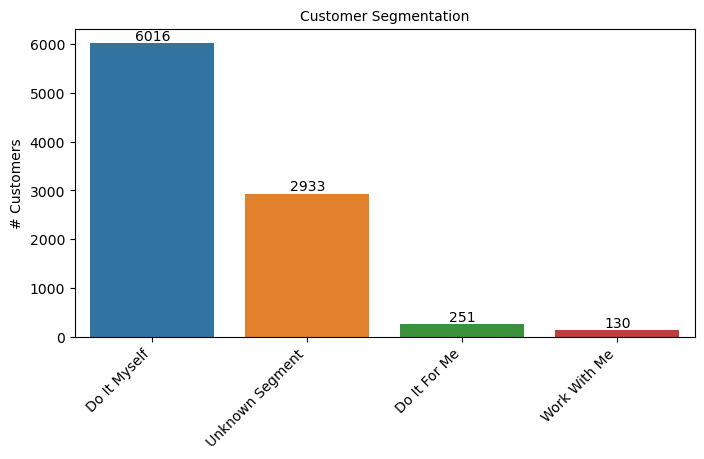

In [27]:
# Customer distribution by Segmentation

custdf_grp = customerdf.groupby(['Segmentation']).size().reset_index(name='counts').sort_values('counts', ascending=False)

plt.figure(figsize =(8,4))
cnt = sn.barplot(x ='Segmentation', y='counts', data=custdf_grp)
for i in cnt.containers:
    cnt.bar_label(i)
    
cnt.set(xlabel='', ylabel='# Customers')
plt.xticks(rotation=45, ha='right')
plt.title("Customer Segmentation", fontsize=10)
plt.show()

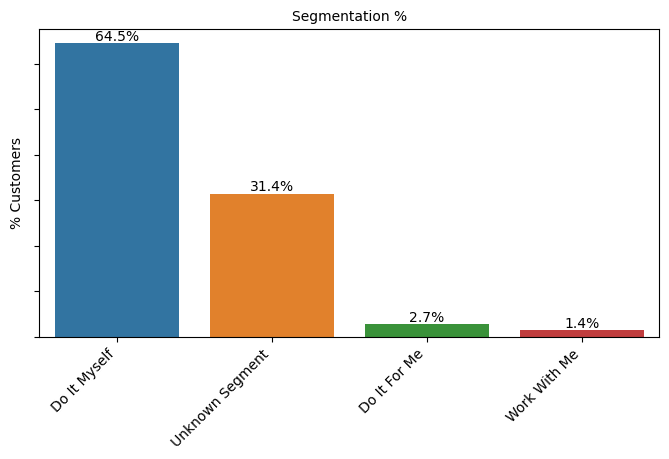

In [28]:
# Customer Segmentation - as % of Customers

# Total count of rows
total_rows = len(customerdf.index)

# Calculate the percent of each label
custdf_grp['pct'] = custdf_grp['counts'] / total_rows

plt.figure(figsize =(8,4))
cnt = sn.barplot(x="Segmentation", y="pct", data=custdf_grp)

for i in cnt.containers:
    cnt.bar_label(i, fmt='{:.1%}') #fmt='%.1f' 
    cnt.set_yticklabels([])

cnt.set(xlabel='', ylabel='% Customers')
plt.title("Segmentation %", fontsize=10)
plt.xticks(rotation=45, ha='right')
#plt.xlabel('%', rotation=0)
plt.show()


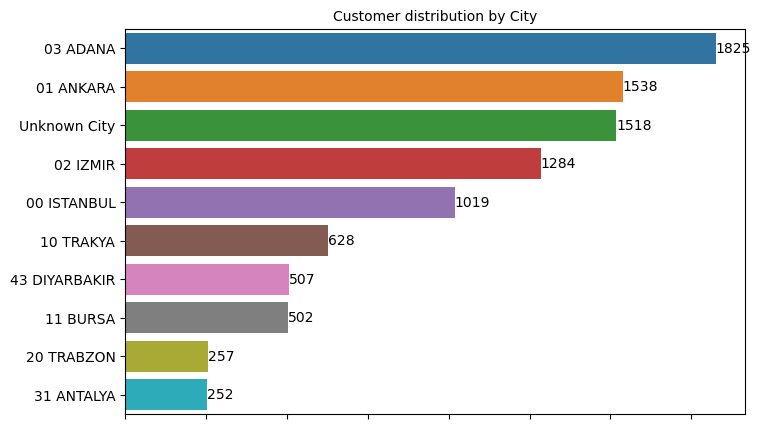

,City,counts
3,03 ADANA,1825
1,01 ANKARA,1538
9,Unknown City,1518
2,02 IZMIR,1284
0,00 ISTANBUL,1019
4,10 TRAKYA,628
8,43 DIYARBAKIR,507
5,11 BURSA,502
6,20 TRABZON,257
7,31 ANTALYA,252


In [29]:
# Customer distribution by City

custdf_city_grp = customerdf.groupby(['City']).size().reset_index(name='counts').sort_values('counts', ascending=False)

plt.figure(figsize =(8,5))
cnt = sn.barplot(x ='counts', y='City', data=custdf_city_grp)
for i in cnt.containers:
    cnt.bar_label(i)
    cnt.set_xticklabels([])
    
cnt.set(xlabel='', ylabel='')
plt.title("Customer distribution by City", fontsize=10)
plt.show()

custdf_city_grp

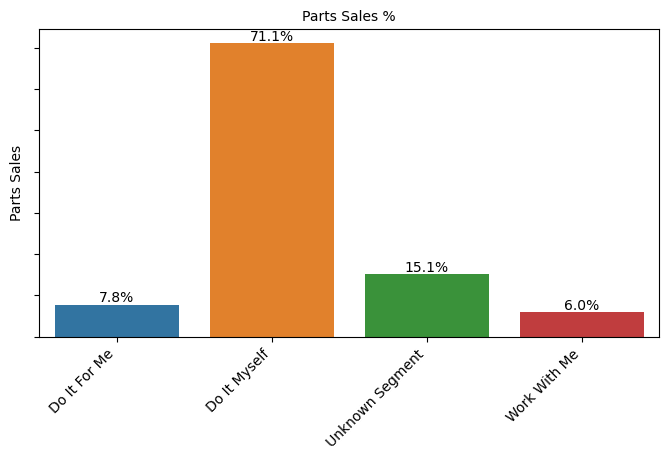

,Segmentation,Parts Sales,pct
0,Do It For Me,3333435,0.077684
1,Do It Myself,30519331,0.711236
2,Unknown Segment,6499546,0.151468
3,Work With Me,2557976,0.059612


In [30]:
# Parts Sales and Opportunity at Segment level

custdf_grp = customerdf.groupby('Segmentation')['Parts Sales'].sum().reset_index()

# Total Parts Sales
total_ps = custdf_grp['Parts Sales'].sum()
#total_ps

# Calculate the percent of each Segment
custdf_grp['pct'] = custdf_grp['Parts Sales'] / total_ps

plt.figure(figsize =(8,4))
cnt = sn.barplot(x="Segmentation", y="pct", data=custdf_grp)

for i in cnt.containers:
    cnt.bar_label(i, fmt='{:.1%}') #fmt='%.1f' 
    cnt.set_yticklabels([])

cnt.set(xlabel='', ylabel='Parts Sales')
plt.title("Parts Sales %", fontsize=10)
plt.xticks(rotation=45, ha='right')
#plt.xlabel('%', rotation=0)
plt.show()

custdf_grp

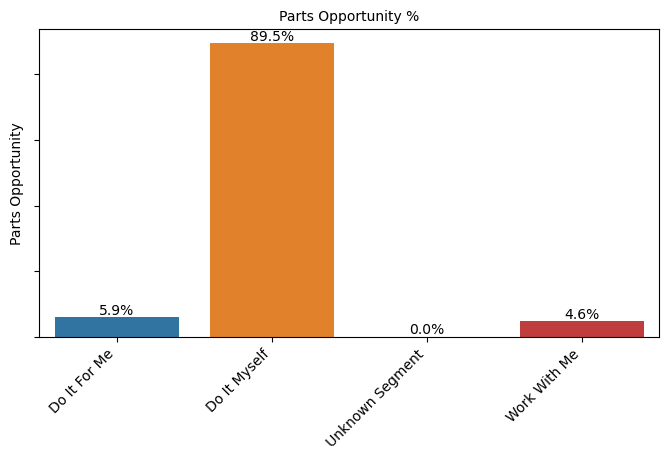

,Segmentation,Parts Opportunity,pct
0,Do It For Me,4262869,5.859320e-02
1,Do It Myself,65136376,8.953005e-01
2,Unknown Segment,6,8.247010e-08
3,Work With Me,3354393,4.610619e-02


In [31]:
# Parts Sales and Opportunity at Segment level

custdf_grp = customerdf.groupby('Segmentation')['Parts Opportunity'].sum().reset_index()

# Total Parts Sales
total_ps = custdf_grp['Parts Opportunity'].sum()
#total_ps

# Calculate the percent of each Segment
custdf_grp['pct'] = custdf_grp['Parts Opportunity'] / total_ps

plt.figure(figsize =(8,4))
cnt = sn.barplot(x="Segmentation", y="pct", data=custdf_grp)

for i in cnt.containers:
    cnt.bar_label(i, fmt='{:.1%}') #fmt='%.1f' 
    cnt.set_yticklabels([])

cnt.set(xlabel='', ylabel='Parts Opportunity')
plt.title("Parts Opportunity %", fontsize=10)
plt.xticks(rotation=45, ha='right')
#plt.xlabel('%', rotation=0)
plt.show()

custdf_grp

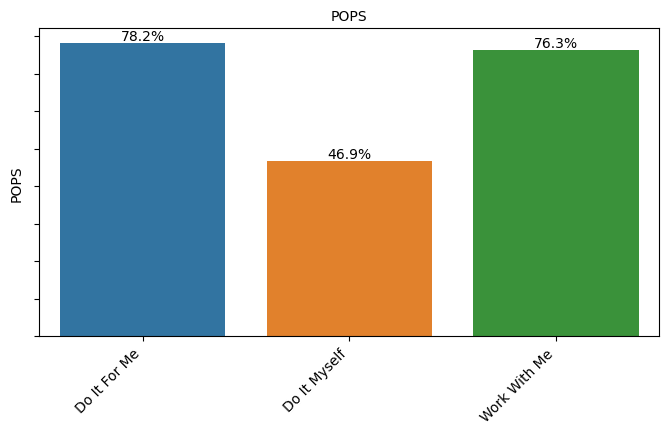

,Segmentation,Parts Sales,Parts Opportunity,POPS
0,Do It For Me,3333435,4262869,7.819698e-01
1,Do It Myself,30519331,65136376,4.685451e-01
2,Unknown Segment,6499546,6,1.083258e+06
3,Work With Me,2557976,3354393,7.625749e-01


In [32]:
# POPS - Percentage of Parts Sales  

# POPS at Segmentation level
custdf_grp = customerdf.groupby('Segmentation')[['Parts Sales', 'Parts Opportunity']].sum().reset_index()
custdf_grp['POPS'] = custdf_grp['Parts Sales'] / custdf_grp['Parts Opportunity']

plt.figure(figsize =(8,4))
cnt = sn.barplot(x="Segmentation", y="POPS", data=custdf_grp[(custdf_grp['Parts Sales'] >= 100) & (custdf_grp['Parts Opportunity'] >= 100)])

for i in cnt.containers:
    cnt.bar_label(i, fmt='{:.1%}') #fmt='%.1f' 
    cnt.set_yticklabels([])

cnt.set(xlabel='', ylabel='POPS')
plt.title("POPS", fontsize=10)
plt.xticks(rotation=45, ha='right')
#plt.xlabel('%', rotation=0)
plt.show()

custdf_grp

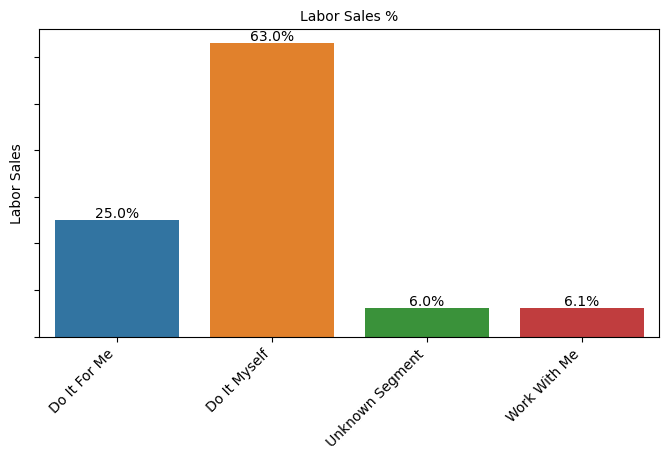

,Segmentation,Labor Sales,pct
0,Do It For Me,2805047,0.249612
1,Do It Myself,7074578,0.629544
2,Unknown Segment,678086,0.060341
3,Work With Me,679912,0.060503


In [33]:
# Labor Sales and Opportunity at Segment level

custdf_grp = customerdf.groupby('Segmentation')['Labor Sales'].sum().reset_index()

# Total Parts Sales
total_ps = custdf_grp['Labor Sales'].sum()
#total_ps

# Calculate the percent of each Segment
custdf_grp['pct'] = custdf_grp['Labor Sales'] / total_ps

plt.figure(figsize =(8,4))
cnt = sn.barplot(x="Segmentation", y="pct", data=custdf_grp)

for i in cnt.containers:
    cnt.bar_label(i, fmt='{:.1%}') #fmt='%.1f' 
    cnt.set_yticklabels([])

cnt.set(xlabel='', ylabel='Labor Sales')
plt.title("Labor Sales %", fontsize=10)
plt.xticks(rotation=45, ha='right')
#plt.xlabel('%', rotation=0)
plt.show()

custdf_grp

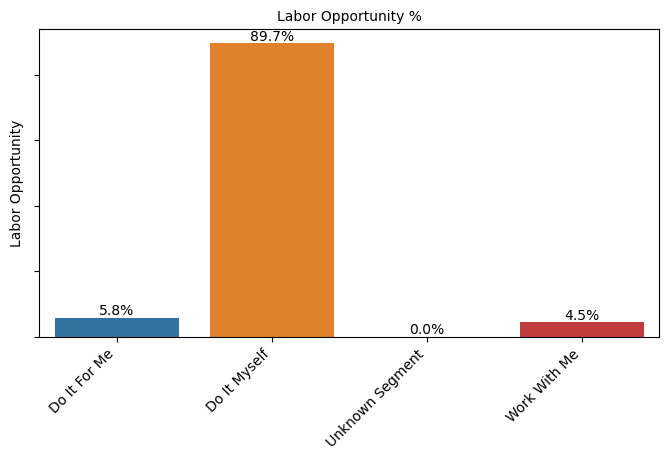

,Segmentation,Labor Opportunity,pct
0,Do It For Me,1756211,0.057617
1,Do It Myself,27349619,0.897269
2,Unknown Segment,0,0.000000
3,Work With Me,1375114,0.045114


In [34]:
# Labor Sales and Opportunity at Segment level

custdf_grp = customerdf.groupby('Segmentation')['Labor Opportunity'].sum().reset_index()

# Total Parts Sales
total_ps = custdf_grp['Labor Opportunity'].sum()
#total_ps

# Calculate the percent of each Segment
custdf_grp['pct'] = custdf_grp['Labor Opportunity'] / total_ps

plt.figure(figsize =(8,4))
cnt = sn.barplot(x="Segmentation", y="pct", data=custdf_grp)

for i in cnt.containers:
    cnt.bar_label(i, fmt='{:.1%}') #fmt='%.1f' 
    cnt.set_yticklabels([])

cnt.set(xlabel='', ylabel='Labor Opportunity')
plt.title("Labor Opportunity %", fontsize=10)
plt.xticks(rotation=45, ha='right')
#plt.xlabel('%', rotation=0)
plt.show()

custdf_grp

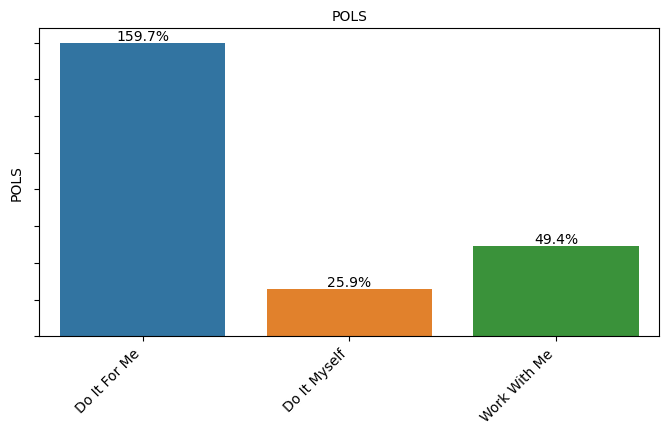

,Segmentation,Labor Sales,Labor Opportunity,POLS
0,Do It For Me,2805047,1756211,1.597215
1,Do It Myself,7074578,27349619,0.258672
2,Unknown Segment,678086,0,inf
3,Work With Me,679912,1375114,0.494440


In [35]:
# POLS - Percentage of Labor Sales  

# POLS at Segmentation level
custdf_grp = customerdf.groupby('Segmentation')[['Labor Sales', 'Labor Opportunity']].sum().reset_index()
custdf_grp['POLS'] = custdf_grp['Labor Sales'] / custdf_grp['Labor Opportunity']

plt.figure(figsize =(8,4))
cnt = sn.barplot(x="Segmentation", y="POLS", data=custdf_grp[(custdf_grp['Labor Sales'] >= 100) & (custdf_grp['Labor Opportunity'] >= 100)])

for i in cnt.containers:
    cnt.bar_label(i, fmt='{:.1%}') #fmt='%.1f' 
    cnt.set_yticklabels([])

cnt.set(xlabel='', ylabel='POLS')
plt.title("POLS", fontsize=10)
plt.xticks(rotation=45, ha='right')
#plt.xlabel('%', rotation=0)
plt.show()

custdf_grp

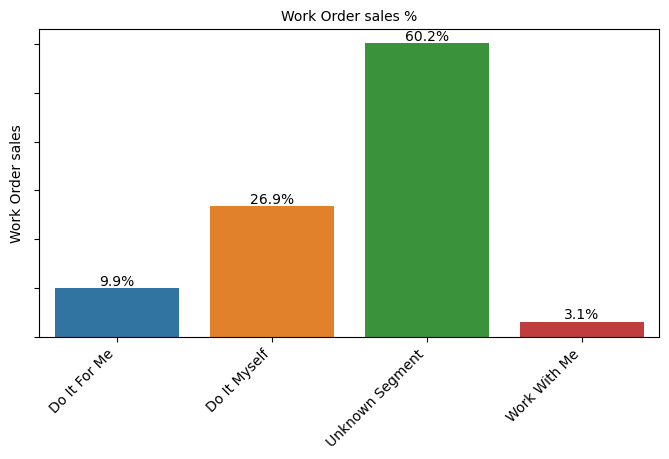

,Segmentation,Work Order sales,pct
0,Do It For Me,3675168,0.098739
1,Do It Myself,9995968,0.268557
2,Unknown Segment,22412893,0.602157
3,Work With Me,1136979,0.030547


In [36]:
# Work Order Sales at Segment level

custdf_grp = customerdf.groupby('Segmentation')['Work Order sales'].sum().reset_index()

# Total Parts Sales
total_ps = custdf_grp['Work Order sales'].sum()
#total_ps

# Calculate the percent of each Segment
custdf_grp['pct'] = custdf_grp['Work Order sales'] / total_ps

plt.figure(figsize =(8,4))
cnt = sn.barplot(x="Segmentation", y="pct", data=custdf_grp)

for i in cnt.containers:
    cnt.bar_label(i, fmt='{:.1%}') #fmt='%.1f' 
    cnt.set_yticklabels([])

cnt.set(xlabel='', ylabel='Work Order sales')
plt.title("Work Order sales %", fontsize=10)
plt.xticks(rotation=45, ha='right')
#plt.xlabel('%', rotation=0)
plt.show()

custdf_grp

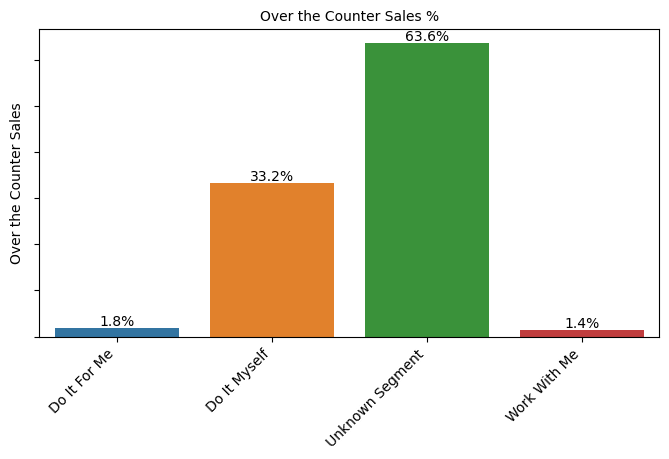

,Segmentation,Over the Counter Sales,pct
0,Do It For Me,754211,0.017939
1,Do It Myself,13966113,0.332183
2,Unknown Segment,26737486,0.635948
3,Work With Me,585668,0.013930


In [37]:
# Over the counter Sales at Segment level

custdf_grp = customerdf.groupby('Segmentation')['Over the Counter Sales'].sum().reset_index()

# Total Parts Sales
total_ps = custdf_grp['Over the Counter Sales'].sum()
#total_ps

# Calculate the percent of each Segment
custdf_grp['pct'] = custdf_grp['Over the Counter Sales'] / total_ps

plt.figure(figsize =(8,4))
cnt = sn.barplot(x="Segmentation", y="pct", data=custdf_grp)

for i in cnt.containers:
    cnt.bar_label(i, fmt='{:.1%}') #fmt='%.1f' 
    cnt.set_yticklabels([])

cnt.set(xlabel='', ylabel='Over the Counter Sales')
plt.title("Over the Counter Sales %", fontsize=10)
plt.xticks(rotation=45, ha='right')
#plt.xlabel('%', rotation=0)
plt.show()

custdf_grp

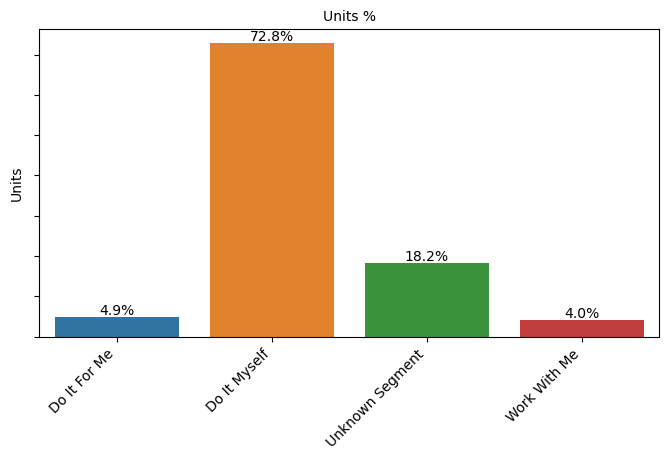

,Segmentation,Units,pct
0,Do It For Me,1126,0.049023
1,Do It Myself,16731,0.728417
2,Unknown Segment,4190,0.182420
3,Work With Me,922,0.040141


In [38]:
# Number of units owned at Segment level

custdf_grp = customerdf.groupby('Segmentation')['Units'].sum().reset_index()

# Total Parts Sales
total_ps = custdf_grp['Units'].sum()
#total_ps

# Calculate the percent of each Segment
custdf_grp['pct'] = custdf_grp['Units'] / total_ps

plt.figure(figsize =(8,4))
cnt = sn.barplot(x="Segmentation", y="pct", data=custdf_grp)

for i in cnt.containers:
    cnt.bar_label(i, fmt='{:.1%}') #fmt='%.1f' 
    cnt.set_yticklabels([])

cnt.set(xlabel='', ylabel='Units')
plt.title("Units %", fontsize=10)
plt.xticks(rotation=45, ha='right')
#plt.xlabel('%', rotation=0)
plt.show()

custdf_grp

##### Key Insights

* **'Do It Myself' segment is the high impact segment**
    * 65% Customers belong to 'Do It Myself' segment and own 73% of the units
    * This segment contributes to 71% of total Parts Sales and 90% of total Parts Opportunities
    * Only 47% of the Parts opportunities are converted into Sales
    * This segment contributes to 63% of total Labor Sales and 90% of total Labor Opportunities 
    * Only 26% of the Labor opportunities are converted into Sales  
* **Customers with no segment assigned do not have opportunity information captured**
    * 30% of Customers have no Segment assigned yet and own 18% of units 
    * This segment contributes to 15% of total Parts Sales and 6% of total Labor Sales 
    * Opportunity data is 0% for this segment 
* **'Do It For Me' and 'Work With Me' together make up only 9% of the customer base**
    * 'Do It For Me' and 'Work With Me' segments together contribute to less than 15% of total Parts Sales, but their opportunity to Sales conversion is greater than 75% for Parts  
    * 'Do It For Me' segment contributes to 25% of total Labor Sales with an opportunity to Sales conversion of 159% 
    * 'Work With Me' segment contributes to only 6% of total Labor Sales with an opportunity to Sales conversion of 25%

##### Recommendations
* Identify why more than 50% of opportunities couldn't be converted to sales for 'Do It Myself' segment
* Identify if Customers belonging to Unknown or No Product Segment Assigned segments are new customers? Why don't we have any opportunities for these? 

###### Next Steps - Further analysis
* Identify if any City or Part can help in increasing the Parts Sales and Labor Sales for 'Do It Myself' segment
* Similarly, identify if  'Do It For Me' and 'Work With Me' segments accounting to only 31% of total Labor Sales is uniform across cities
* Rank parts based on their Opportunity to Sales conversion ratio and identify high/low performing Parts 
* Parts sales without an associated Labor sales - how many customers or which parts?
* Focus on high opportunity customers 